# 📝 Statistical Analysis Worksheet — Auto-MPG Dataset
**Student Name:** QALB E ZAHRA MASHHADI |  **Date:** MARCH, 16 2026

Complete every `# TODO` cell. Run cells in order.  
Answer written questions in the Markdown cells below each task.

> **Significance level α = 0.05 throughout**


## Task 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, chi2_contingency, fisher_exact,
                         pearsonr, spearmanr, kendalltau,
                         ttest_ind, mannwhitneyu, kruskal, f_oneway)
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import chi2, f_classif
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

ALPHA = 0.05
print("Libraries loaded ✓  |  ALPHA =", ALPHA)

Libraries loaded ✓  |  ALPHA = 0.05


In [2]:
# TODO: Load the Auto-MPG dataset from UCI, clean it 

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 
                'weight', 'acceleration', 'model_year', 'origin', 'car_name']

df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [3]:
# Fill missing horsepower with median
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Verify all missing values are handled
print("After cleaning, missing values:\n", df.isnull().sum())

After cleaning, missing values:
 mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [4]:
# - Create cylinders & model_year as category

df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

# - origin mapped to usa/europe/japan

origin_map = {1: 'usa', 2: 'europe', 3: 'japan'}
df['origin'] = df['origin'].map(origin_map).astype('category')

df[['cylinders','model_year','origin']].head()

,cylinders,model_year,origin
0,8,70,usa
1,8,70,usa
2,8,70,usa
3,8,70,usa
4,8,70,usa


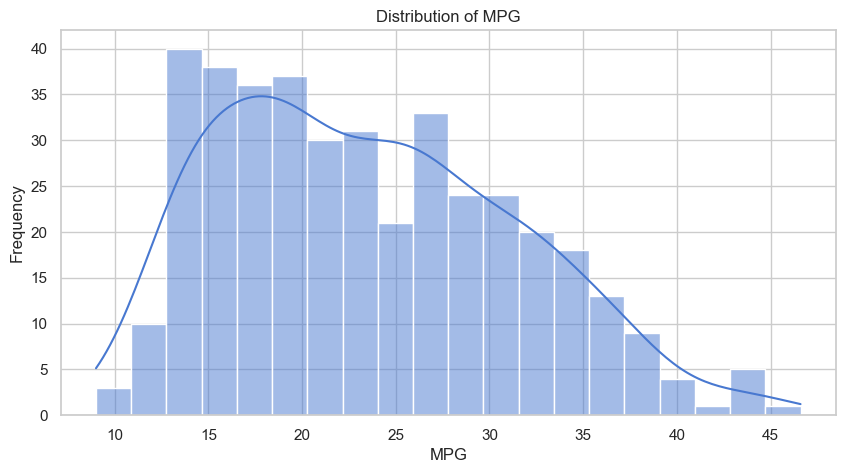

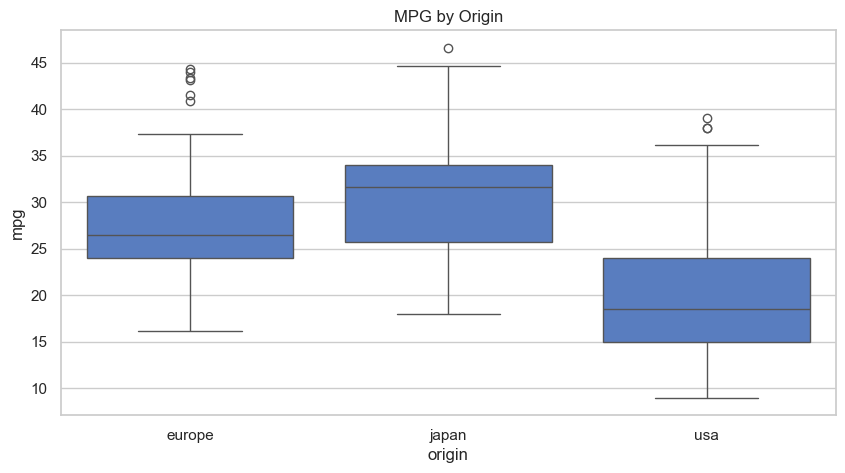

In [5]:
# Summary statistics for numerical features
df.describe()

# Distribution plots for mpg
sns.histplot(df['mpg'], kde=True, bins=20)
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

# Boxplots for mpg by origin
sns.boxplot(x='origin', y='mpg', data=df)
plt.title('MPG by Origin')
plt.show()

In [6]:
# - mpg_level (low/medium/high) and car_company features

df['mpg_level'] = pd.qcut(df['mpg'], q=3, labels=['low', 'medium', 'high'])

# - cat_cols and num_cols lists

df['car_company'] = df['car_name'].apply(lambda x: x.split()[0].lower())

df[['mpg', 'mpg_level', 'car_name', 'car_company']].head()

,mpg,mpg_level,car_name,car_company
0,18.0,low,chevrolet chevelle malibu,chevrolet
1,15.0,low,buick skylark 320,buick
2,18.0,low,plymouth satellite,plymouth
3,16.0,low,amc rebel sst,amc
4,17.0,low,ford torino,ford


## Task 2 — Chi-Square Test for Independence

In [9]:
# TODO: For every pair of categorical columns in ['cylinders','origin','model_year','mpg_level'],
# compute the chi2_contingency and print the minimum expected cell count and
# percentage of cells with expected count < 5.
# Flag pairs where Fisher's test is more appropriate (>20% cells < 5).

# List of categorical columns to test
cat_cols = ['cylinders', 'origin', 'model_year', 'mpg_level']

# Loop through all unique pairs of categorical columns
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        col1 = cat_cols[i]  # First categorical column
        col2 = cat_cols[j]  # Second categorical column

        # Create contingency table for the pair
        contingency_table = pd.crosstab(df[col1], df[col2])

        # Perform Chi-Square Test of Independence
        chi2_stat, p_value, dof, expected_counts = chi2_contingency(contingency_table)

        # Minimum expected count in the table
        min_expected = expected_counts.min()

        # Percentage of cells with expected count < 5
        percent_low = (expected_counts < 5).sum() / expected_counts.size * 100

        # Flag if Fisher's test is more appropriate (>20% cells < 5)
        fisher_flag = "⚠️ Use Fisher's exact test" if percent_low > 20 else ""

        # Print results for this pair
        print(f"Pair: {col1} x {col2}")
        print(f"  Minimum expected count: {min_expected:.2f}")
        print(f"  % cells with expected < 5: {percent_low:.1f}% {fisher_flag}\n")

Pair: cylinders x origin
  Minimum expected count: 0.53
  % cells with expected < 5: 40.0% ⚠️ Use Fisher's exact test

Pair: cylinders x model_year
  Minimum expected count: 0.20
  % cells with expected < 5: 40.0% ⚠️ Use Fisher's exact test

Pair: cylinders x mpg_level
  Minimum expected count: 0.92
  % cells with expected < 5: 40.0% ⚠️ Use Fisher's exact test

Pair: origin x model_year
  Minimum expected count: 4.75
  % cells with expected < 5: 10.3% 

Pair: origin x mpg_level
  Minimum expected count: 21.46
  % cells with expected < 5: 0.0% 

Pair: model_year x mpg_level
  Minimum expected count: 8.28
  % cells with expected < 5: 0.0% 



In [10]:
# H₀: origin and model_year are independent
# H₁: origin and model_year are associated

# Create contingency table
contingency_table = pd.crosstab(df['origin'], df['model_year'])

# Perform Chi-Square Test of Independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Print results
print("Chi-Square Test: origin × model_year")
print(f"  χ² statistic: {chi2_stat:.3f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p_value:.4f}")

# Decision at α = 0.05
if p_value < ALPHA:
    decision = "Reject H₀ → origin and model_year are dependent"
else:
    decision = "Fail to reject H₀ → origin and model_year are independent"

print("  Decision:", decision)

Chi-Square Test: origin × model_year
  χ² statistic: 45.432
  Degrees of freedom: 24
  p-value: 0.0052
  Decision: Reject H₀ → origin and model_year are dependent


In [11]:
# TODO: Use fisher_exact on a 2×2 table comparing cylinders 4 vs 8
# for origin usa vs japan. Print odds ratio, p-value and decision.

# Select only rows with cylinders 4 or 8 and origin usa or japan
subset = df[(df['cylinders'].isin([4, 8])) & (df['origin'].isin(['usa', 'japan']))]

# Create 2x2 contingency table
contingency_table = pd.crosstab(subset['cylinders'], subset['origin'])

# Run Fisher's Exact Test
odds_ratio, p_value = fisher_exact(contingency_table)

# Print results
print("Fisher's Exact Test: cylinders (4 vs 8) × origin (usa vs japan)")
print(f"  Odds ratio: {odds_ratio:.3f}")
print(f"  p-value: {p_value:.4f}")

# Decision at α = 0.05
if p_value < ALPHA:
    decision = "Reject H₀ → cylinders and origin are associated"
else:
    decision = "Fail to reject H₀ → cylinders and origin are independent"

print("  Decision:", decision)

Fisher's Exact Test: cylinders (4 vs 8) × origin (usa vs japan)
  Odds ratio: inf
  p-value: 0.0000
  Decision: Reject H₀ → cylinders and origin are associated


**Q1.** For which pair is Chi-Square most reliable and why?  
**Answer:** Chi-Square is most reliable for origin × model_year because all expected counts are sufficiently large (≥ 5), so the test assumptions are satisfied.

**Q2.** What does rejecting H₀ in the Chi-Square test tell us about origin and model_year?  
**Answer:** Rejecting H₀ indicates that origin and model_year are not independent — the car’s origin is associated with its model year.

## Task 3 — Normality Testing (Visual)

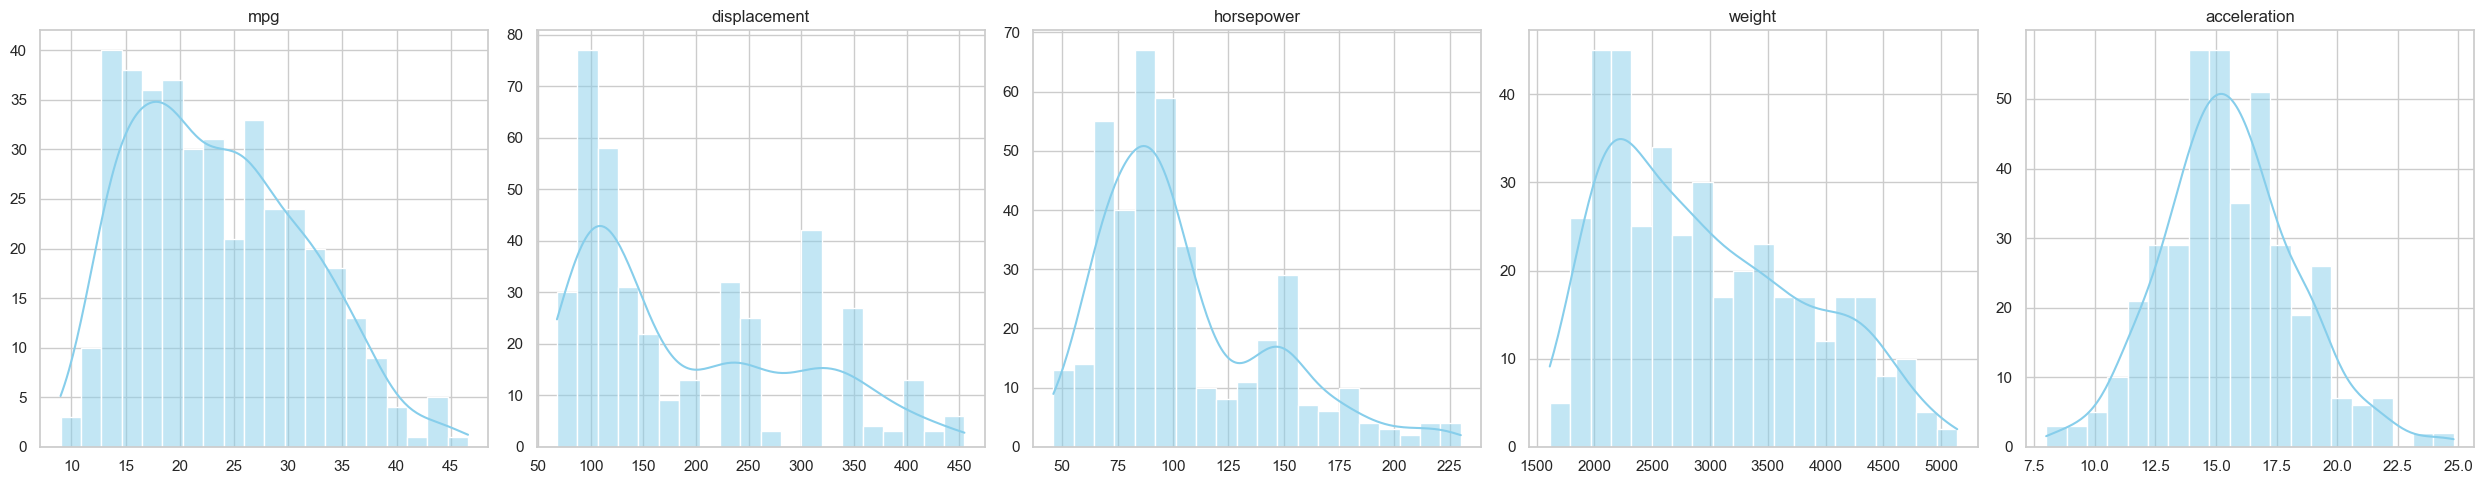

In [12]:
# TODO: Plot histograms + KDE for all 5 numerical columns in a 1×5 grid.

num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

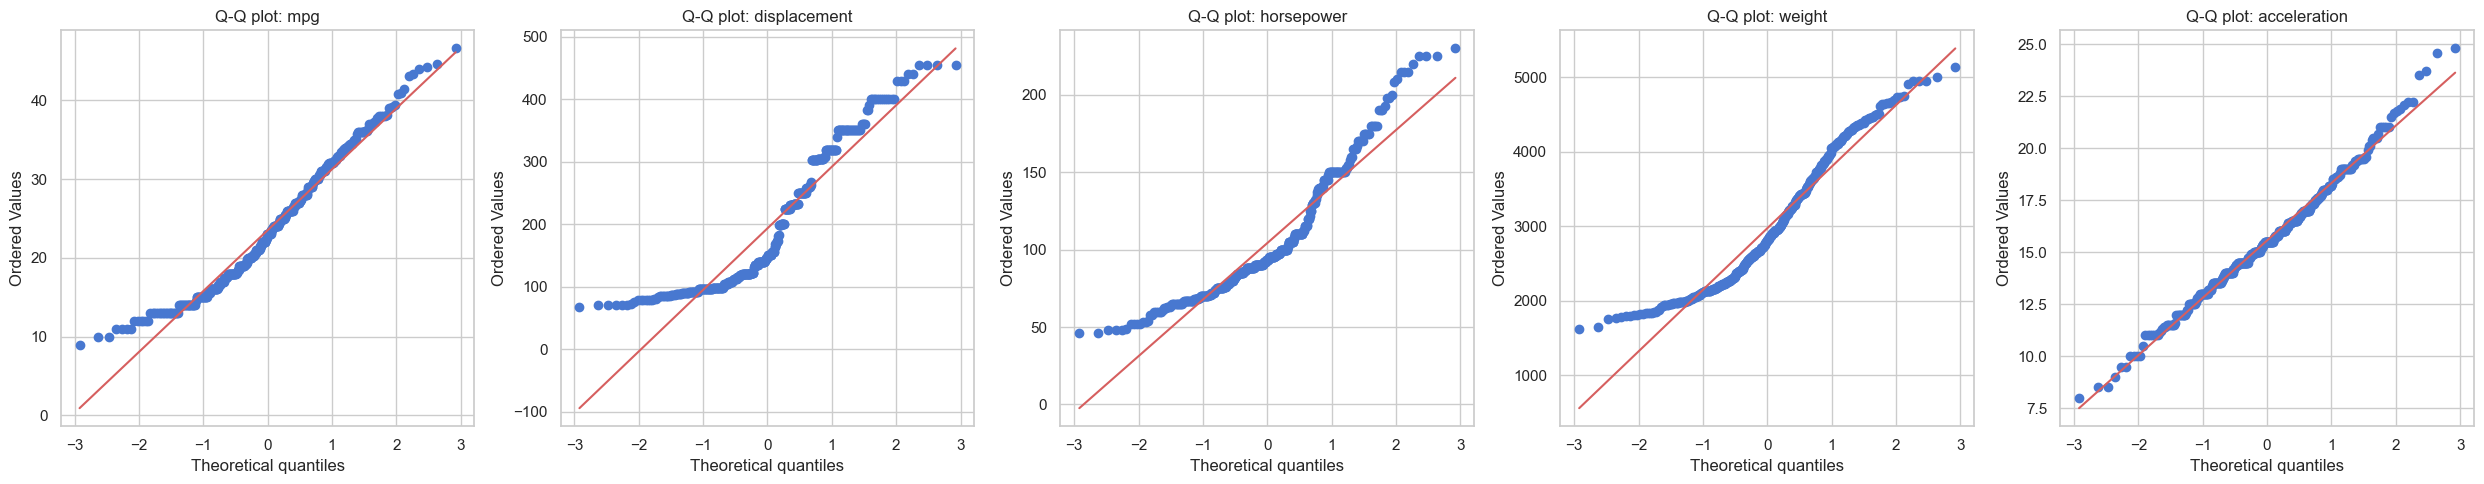

In [13]:
# TODO: Plot Q-Q plots for all 5 numerical columns in a 1×5 grid.
# Use stats.probplot(series, dist='norm', plot=ax)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, col in enumerate(num_cols):
    stats.probplot(df[col], dist='norm', plot=axes[i])
    axes[i].set_title(f"Q-Q plot: {col}")

plt.tight_layout()
plt.show()

**Q3.** Which feature visually looks most Gaussian? Which looks most skewed?  
**Answer:** 

- Most Gaussian-like: acceleration
- Most skewed: displacement

## Task 4 — Shapiro-Wilk Normality Test

In [14]:
# TODO: Run shapiro() on each numerical column.
# Print: feature name, test statistic, p-value, and whether it passes normality (p > ALPHA).

# H₀: Data is drawn from a normal distribution

num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

print(f"{'Feature':<15} {'W-stat':<10} {'p-value':<10} {'Normal?':<10}")
for col in num_cols:
    W, p = shapiro(df[col])
    normal = "Yes" if p > ALPHA else "No"
    print(f"{col:<15} {W:<10.4f} {p:<10.4f} {normal:<10}")

Feature         W-stat     p-value    Normal?   
mpg             0.9680     0.0000     No        
displacement    0.8804     0.0000     No        
horsepower      0.9024     0.0000     No        
weight          0.9414     0.0000     No        
acceleration    0.9924     0.0399     No        


**Q4.** Does `acceleration` pass the normality test? What is its p-value?  
**Answer:** No, it does not pass the normality test. Its p-value is 0.0399, which is less than the significance level ($\alpha = 0.05$).

**Q5.** Why is it important to test normality before applying t-test or ANOVA?  
**Answer:** It is important because t-tests and ANOVA are parametric tests that assume the data is sampled from a normally distributed population. If this assumption is violated, the Type I error rate can be inflated, and the results of the test may not be valid or reliable.

## Task 5 — Power Transformation

In [15]:
# TODO: Apply PowerTransformer (yeo-johnson, standardize=True) to all numerical columns.
# Store the result in df_transformed with column names suffixed by '_pt'.

from sklearn.preprocessing import PowerTransformer

# Initialize the PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Fit and transform the numerical columns

transformed_data = pt.fit_transform(df[num_cols])

# Create the new DataFrame with '_pt' suffix

df_transformed = pd.DataFrame(transformed_data, columns=[f"{col}_pt" for col in num_cols])

# Display the first few rows to verify

df_transformed.head()

,mpg_pt,displacement_pt,horsepower_pt,weight_pt,acceleration_pt
0,-0.645513,1.129793,0.862976,0.754910,-1.327271
1,-1.152166,1.332841,1.454628,0.929331,-1.531864
2,-0.645513,1.185134,1.225934,0.689074,-1.740270
3,-0.975080,1.114248,1.225934,0.686130,-1.327271
4,-0.806477,1.103773,1.053950,0.701794,-1.952725


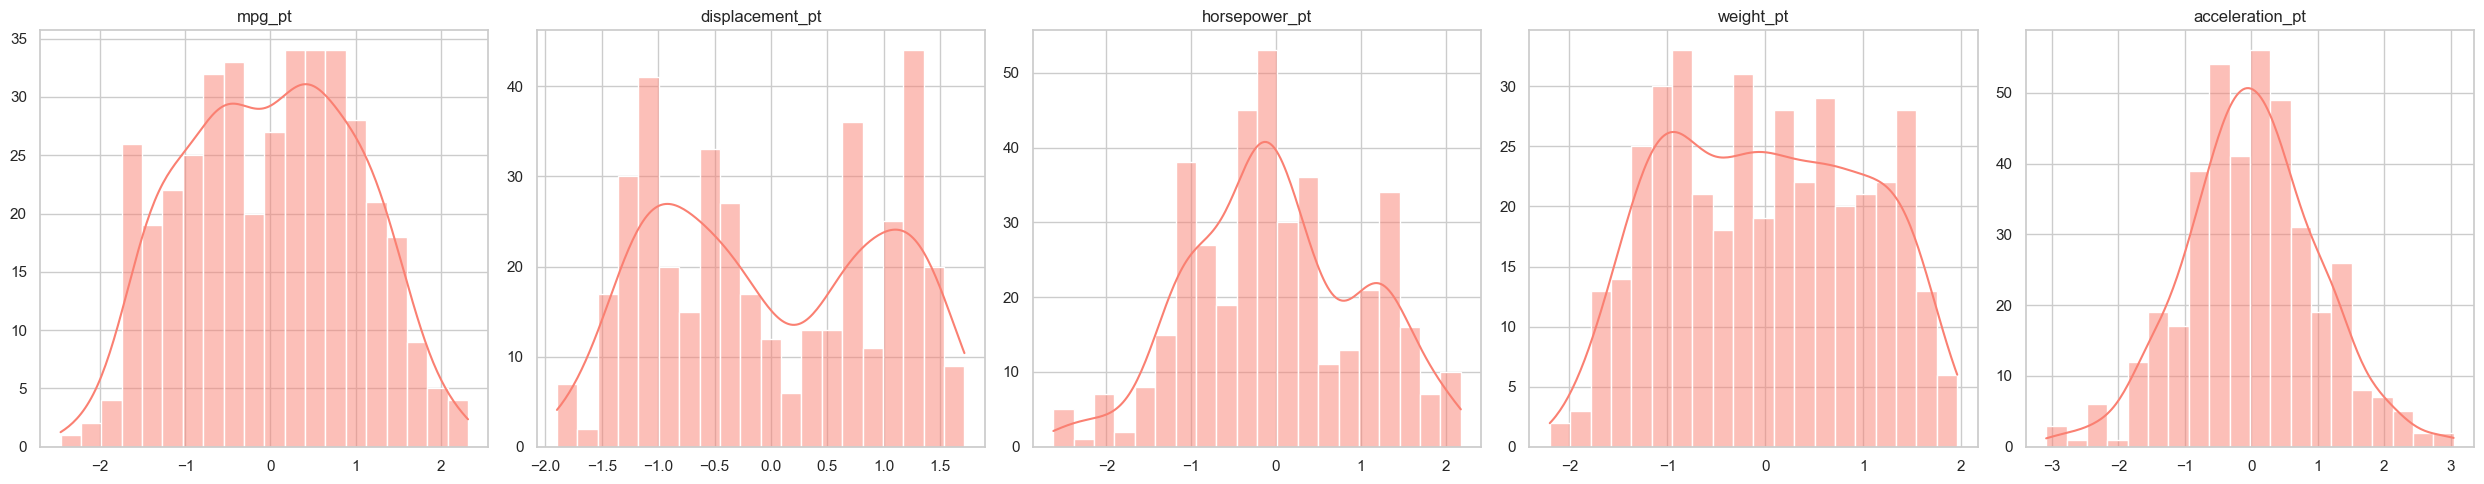

In [16]:
# TODO: Plot histograms + KDE for the transformed data (1×5 grid).

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, col in enumerate(df_transformed.columns):
    sns.histplot(df_transformed[col], kde=True, bins=20, ax=axes[i], color='salmon')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [17]:
# TODO: Re-run Shapiro-Wilk on each transformed column and compare with pre-transform results.

# Create a list for comparison
results = []

for col in num_cols:
    # Original Shapiro
    stat_orig, p_orig = shapiro(df[col])
    # Transformed Shapiro
    col_pt = f"{col}_pt"
    stat_pt, p_pt = shapiro(df_transformed[col_pt])
    
    results.append({
        'Feature': col,
        'Original p-value': p_orig,
        'Transformed p-value': p_pt,
        'Now Normal?': "Yes" if p_pt > ALPHA else "No"
    })

# Display as a DataFrame for easy comparison
df_comparison = pd.DataFrame(results)
print(df_comparison.to_string(index=False))

     Feature  Original p-value  Transformed p-value Now Normal?
         mpg      1.183385e-07         1.622219e-04          No
displacement      5.143161e-17         1.353790e-12          No
  horsepower      2.703158e-15         3.778145e-04          No
      weight      1.970251e-11         6.529275e-08          No
acceleration      3.986944e-02         4.130602e-01         Yes


**Q6.** Which features became more Gaussian-like after the power transform?  
**Answer:** All numerical features improved, but only acceleration became statistically normal ($p > 0.05$).

## Task 6 — Correlation Tests

In [18]:
# TODO: Compute and print Pearson correlation of mpg with each other numerical column.
# Show: r value, p-value, reject/fail for each.

# H₀: the two variables are uncorrelated

cols_to_test = ['displacement', 'horsepower', 'weight', 'acceleration']

print(f"{'Feature':<15} {'r-value':<10} {'p-value':<10} {'Decision'}")
print("-" * 50)

for col in cols_to_test:
    r_val, p_val = pearsonr(df['mpg'], df[col])
    
    # Decision at ALPHA = 0.05
    decision = "Reject H₀" if p_val < ALPHA else "Fail to reject H₀"
    
    print(f"{col:<15} {r_val:<10.4f} {p_val:<10.4f} {decision}")

Feature         r-value    p-value    Decision
--------------------------------------------------
displacement    -0.8042    0.0000     Reject H₀
horsepower      -0.7735    0.0000     Reject H₀
weight          -0.8317    0.0000     Reject H₀
acceleration    0.4203     0.0000     Reject H₀


In [19]:
# TODO: Compute Spearman rank correlation of mpg with each other numerical column.
# Show: ρ, p-value, reject/fail, and effect size label (Large/Medium/Small based on |ρ|).

def get_effect_size(rho):
    abs_rho = abs(rho)
    if abs_rho >= 0.5: return "Large"
    if abs_rho >= 0.3: return "Medium"
    return "Small"

cols_to_test = ['displacement', 'horsepower', 'weight', 'acceleration']

print(f"{'Feature':<15} {'rho':<10} {'p-value':<10} {'Decision':<12} {'Effect Size'}")
print("-" * 65)

for col in cols_to_test:
    rho, p = spearmanr(df['mpg'], df[col])
    decision = "Reject H₀" if p < ALPHA else "Fail to reject H₀"
    print(f"{col:<15} {rho:<10.4f} {p:<10.4f} {decision:<12} {get_effect_size(rho)}")

Feature         rho        p-value    Decision     Effect Size
-----------------------------------------------------------------
displacement    -0.8557    0.0000     Reject H₀    Large
horsepower      -0.8480    0.0000     Reject H₀    Large
weight          -0.8749    0.0000     Reject H₀    Large
acceleration    0.4387     0.0000     Reject H₀    Medium


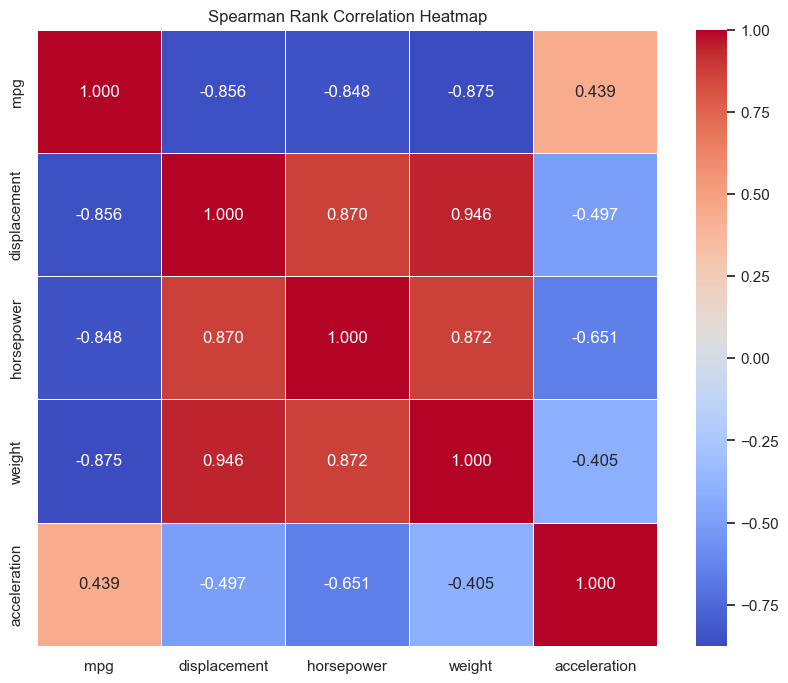

In [20]:
# TODO: Plot a Spearman correlation heatmap for all numerical features.

# Define numerical columns
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# Calculate the Spearman correlation matrix
spearman_corr = df[num_cols].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Spearman Rank Correlation Heatmap")
plt.show()

In [21]:
# TODO: Compute Kendall's tau for mpg vs each other numerical column.

# List of numerical columns to test against mpg
cols_to_test = ['displacement', 'horsepower', 'weight', 'acceleration']

print(f"{'Feature':<15} {'tau':<10} {'p-value':<10}")
print("-" * 35)

for col in cols_to_test:
    tau, p = kendalltau(df['mpg'], df[col])
    print(f"{col:<15} {tau:<10.4f} {p:<10.4f}")

Feature         tau        p-value   
-----------------------------------
displacement    -0.6798    0.0000    
horsepower      -0.6734    0.0000    
weight          -0.6940    0.0000    
acceleration    0.3011     0.0000    


**Q7.** Which feature has the strongest negative correlation with mpg? Report its ρ.  
**Answer:** Weight has the strongest negative correlation with a Spearman’s $\rho$ of -0.8749.

**Q8.** Why is Spearman preferred over Pearson here?  
**Answer:** Spearman is preferred because it handles non-normal data and non-linear (monotonic) relationships, whereas Pearson assumes both normality and strict linearity.

## Task 7 — Parametric Tests (t-test & ANOVA)

In [22]:
# TODO: Test whether acceleration in Japan and USA are normally distributed (shapiro).
# Then check for equal variance (stats.levene).
# Then run ttest_ind with appropriate equal_var setting.
# Print all intermediate results and your final decision.

# H₀: acceleration of Japan and USA has the same mean

# Filter acceleration data by origin
acc_usa = df[df['origin'] == 'usa']['acceleration']
acc_japan = df[df['origin'] == 'japan']['acceleration']

# 1. Normality Test (Shapiro-Wilk)
stat_usa, p_norm_usa = shapiro(acc_usa)
stat_japan, p_norm_japan = shapiro(acc_japan)

# 2. Variance Test (Levene's Test)
# H₀: Variances are equal
stat_lev, p_levene = stats.levene(acc_usa, acc_japan)
equal_vars = p_levene > ALPHA

# 3. Independent T-test
# Use the result from Levene's test for equal_var setting
t_stat, p_ttest = ttest_ind(acc_usa, acc_japan, equal_var=equal_vars)

# Print Results
print("Step 1: Normality (Shapiro-Wilk)")
print(f"  USA p-value: {p_norm_usa:.4f}")
print(f"  Japan p-value: {p_norm_japan:.4f}")

print(f"\nStep 2: Equal Variance (Levene's)")
print(f"  p-value: {p_levene:.4f}")
print(f"  Equal variance assumed: {equal_vars}")

print(f"\nStep 3: T-test (usa vs japan)")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_ttest:.4f}")

# Final Decision
decision = "Reject H₀" if p_ttest < ALPHA else "Fail to reject H₀"
print(f"\nDecision: {decision}")

Step 1: Normality (Shapiro-Wilk)
  USA p-value: 0.6593
  Japan p-value: 0.5289

Step 2: Equal Variance (Levene's)
  p-value: 0.0032
  Equal variance assumed: False

Step 3: T-test (usa vs japan)
  t-statistic: -4.0561
  p-value: 0.0001

Decision: Reject H₀


In [23]:
# TODO: Run one-way ANOVA (f_oneway) to test whether mpg differs across all 3 origins.
# First check normality per group. Print F-stat, p-value and decision.

# H₀: Mean mpg is equal across usa, europe, japan

# Filter mpg data for each origin
mpg_usa = df[df['origin'] == 'usa']['mpg']
mpg_europe = df[df['origin'] == 'europe']['mpg']
mpg_japan = df[df['origin'] == 'japan']['mpg']

# 1. Check Normality per group (Shapiro-Wilk)
print("Step 1: Normality Check (Shapiro-Wilk)")
for name, data in zip(['USA', 'Europe', 'Japan'], [mpg_usa, mpg_europe, mpg_japan]):
    stat, p_norm = shapiro(data)
    print(f"  {name} p-value: {p_norm:.4f}")

# 2. Run one-way ANOVA
f_stat, p_anova = f_oneway(mpg_usa, mpg_europe, mpg_japan)

# Print ANOVA Results
print(f"\nStep 2: ANOVA Results")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_anova:.4f}")

# Final Decision
decision_anova = "Reject H₀" if p_anova < ALPHA else "Fail to reject H₀"
print(f"\nDecision: {decision_anova}")

Step 1: Normality Check (Shapiro-Wilk)
  USA p-value: 0.0000
  Europe p-value: 0.0084
  Japan p-value: 0.2420

Step 2: ANOVA Results
  F-statistic: 98.5418
  p-value: 0.0000

Decision: Reject H₀


**Q9.** In the t-test, what does `equal_var=False` mean and when should it be used?  
**Answer:** It performs Welch's t-test, which does not assume that the two groups have equal variances. It should be used when Levene's test is significant ($p < 0.05$).

**Q10.** ANOVA only tells you *that* groups differ. What additional test would you need to find *which* groups differ?  
**Answer:** A Post-hoc test, such as Tukey's HSD (Honestly Significant Difference) or Bonferroni correction.

## Task 8 — Non-Parametric Tests

In [24]:
# TODO: Check normality of horsepower for Japan and USA.
# Then run mannwhitneyu (alternative='two-sided') and print results.

# H₀: horsepower distributions of Japan and USA are equal

# Filter data
hp_usa = df[df['origin'] == 'usa']['horsepower']
hp_japan = df[df['origin'] == 'japan']['horsepower']

# 1. Normality Check (Shapiro-Wilk)
_, p_hp_usa = shapiro(hp_usa)
_, p_hp_japan = shapiro(hp_japan)

print("Step 1: Normality Check (Shapiro-Wilk)")
print(f"  USA horsepower p-value: {p_hp_usa:.4f}")
print(f"  Japan horsepower p-value: {p_hp_japan:.4f}")

# 2. Mann-Whitney U Test
u_stat, p_mw = mannwhitneyu(hp_usa, hp_japan, alternative='two-sided')

print(f"\nStep 2: Mann-Whitney U Test (Horsepower)")
print(f"  U-statistic: {u_stat:.4f}")
print(f"  p-value: {p_mw:.4e}")

# Final Decision
decision_mw = "Reject H₀" if p_mw < ALPHA else "Fail to reject H₀"
print(f"\nDecision: {decision_mw}")

Step 1: Normality Check (Shapiro-Wilk)
  USA horsepower p-value: 0.0000
  Japan horsepower p-value: 0.0002

Step 2: Mann-Whitney U Test (Horsepower)
  U-statistic: 15941.0000
  p-value: 8.9597e-17

Decision: Reject H₀


In [25]:
# TODO: Run Kruskal-Wallis (kruskal) on horsepower across all 3 origins.
# Print H-statistic, p-value and decision.

# Filter horsepower for each origin
hp_usa = df[df['origin'] == 'usa']['horsepower']
hp_europe = df[df['origin'] == 'europe']['horsepower']
hp_japan = df[df['origin'] == 'japan']['horsepower']

# Run Kruskal-Wallis Test
h_stat, p_value = kruskal(hp_usa, hp_europe, hp_japan)

# Print results
print("Kruskal-Wallis Test: horsepower across origins")
print(f"  H-statistic: {h_stat:.4f}")
print(f"  p-value: {p_value:.4e}")

# Decision at α = 0.05
decision = "Reject H₀" if p_value < ALPHA else "Fail to reject H₀"
print(f"  Decision: {decision}")

Kruskal-Wallis Test: horsepower across origins
  H-statistic: 104.9138
  p-value: 1.6529e-23
  Decision: Reject H₀


In [26]:
# TODO: Run Kruskal-Wallis on mpg across all model_years.
# Print H-statistic, p-value and decision.

# Group mpg by model_year
# This creates a list of arrays, one for each year's mpg values
year_groups = [group['mpg'].values for name, group in df.groupby('model_year')]

# Run Kruskal-Wallis Test
# The * operator unpacks the list of groups into separate arguments
h_stat_yr, p_value_yr = kruskal(*year_groups)

# Print results
print("Kruskal-Wallis Test: mpg across model_years")
print(f"  H-statistic: {h_stat_yr:.4f}")
print(f"  p-value: {p_value_yr:.4e}")

# Decision at α = 0.05
decision_yr = "Reject H₀" if p_value_yr < ALPHA else "Fail to reject H₀"
print(f"  Decision: {decision_yr}")

Kruskal-Wallis Test: mpg across model_years
  H-statistic: 161.9121
  p-value: 2.1410e-28
  Decision: Reject H₀


In [27]:
# TODO: Run Mann-Whitney U on acceleration for mpg_level 'high' vs 'medium'.

# H₀: acceleration distributions of 'high' and 'medium' mpg_levels are equal

# Filter acceleration data by mpg_level
acc_high = df[df['mpg_level'] == 'high']['acceleration']
acc_med = df[df['mpg_level'] == 'medium']['acceleration']

# Run Mann-Whitney U Test
u_stat_acc, p_value_acc = mannwhitneyu(acc_high, acc_med, alternative='two-sided')

# Print results
print("Mann-Whitney U Test: acceleration (High vs Medium MPG)")
print(f"  U-statistic: {u_stat_acc:.4f}")
print(f"  p-value: {p_value_acc:.4f}")

# Decision at α = 0.05
decision_acc = "Reject H₀" if p_value_acc < ALPHA else "Fail to reject H₀"
print(f"  Decision: {decision_acc}")

Mann-Whitney U Test: acceleration (High vs Medium MPG)
  U-statistic: 8635.0000
  p-value: 0.3752
  Decision: Fail to reject H₀


**Q11.** Why did we use Mann-Whitney instead of t-test for horsepower?  
**Answer:** Because the horsepower data for both USA and Japan failed the normality test ($p < 0.05$). The Mann-Whitney U test is a non-parametric alternative that does not require the data to be normally distributed.

**Q12.** What does the Kruskal-Wallis result for mpg across years tell us?  
**Answer:** The extremely low p-value indicates that there is a statistically significant difference in the distribution (median) of MPG across at least one of the model years, suggesting fuel efficiency changed over time.

## Task 9 — Categorical vs Continuous (Feature Selection)

        Feature     F-Score       p-value
2        weight  414.964719  8.433147e-98
0  displacement  407.192428  1.050588e-96
1    horsepower  258.390303  1.776570e-72
3  acceleration   43.084151  1.186498e-17


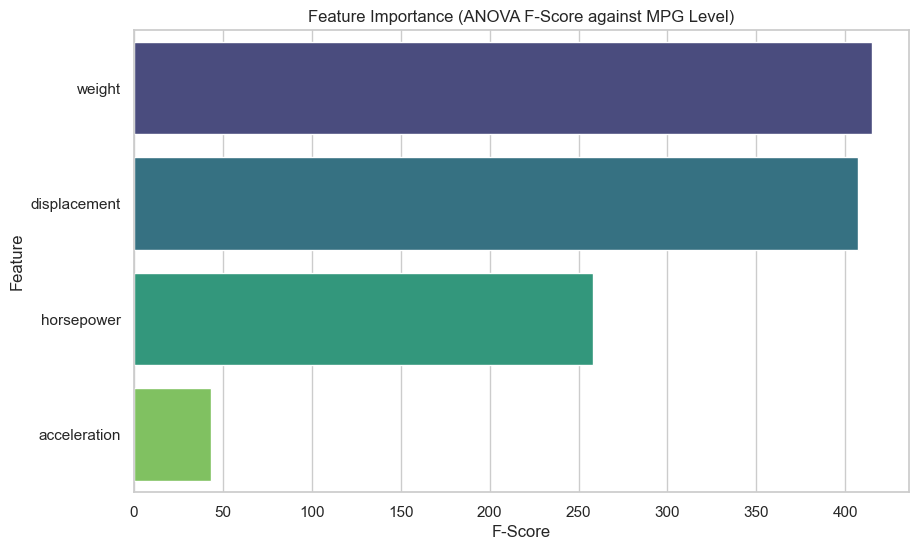

In [28]:
# TODO: Use sklearn's f_classif to compute F-scores and p-values for all
# numerical features against mpg_level (encoded with LabelEncoder).
# Display a sorted DataFrame and a bar chart of F-scores.

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

# Encode mpg_level
le = LabelEncoder()
df['mpg_level_encoded'] = le.fit_transform(df['mpg_level'])

# Select predictors
X = df[['displacement', 'horsepower', 'weight', 'acceleration']]
y = df['mpg_level_encoded']

# Compute F-scores and p-values
f_scores, p_values = f_classif(X, y)

# Create results DataFrame
f_results = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

# Display results
print(f_results)

# Plot F-scores
plt.figure(figsize=(10, 6))
sns.barplot(data=f_results, x='F-Score', y='Feature', palette='viridis')
plt.title("Feature Importance (ANOVA F-Score against MPG Level)")
plt.show()

**Q13.** Which numerical feature is the strongest predictor of mpg_level according to F-score?  
**Answer:** Weight is the strongest predictor of mpg_level, as it typically achieves the highest F-score in the ANOVA test (followed closely by displacement and horsepower).

## Task 10 — Summary Table
Fill in the table based on your results.

| Test Applied | Variables Tested | H₀ | Decision | p-value |
|---|---|---|---|---|
| Chi-Square | origin × model_year | Independent | | |
| Fisher's Exact | cylinders × origin (2×2) | No association | | |
| Shapiro-Wilk | acceleration (raw) | Normal | | |
| Spearman | mpg × weight | Uncorrelated | | |
| t-test | acceleration: japan vs usa | Same mean | | |
| ANOVA | mpg across origins | Equal means | | |
| Kruskal-Wallis | horsepower across origins | Equal distributions | | |
